In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load dataset

df = pd.read_csv('employee_salary_dataset.csv')

# Check missing values
print(df.isnull().sum())

# Remove duplicates

df.drop_duplicates(inplace=True)
# Encode categorical variables
label_encoder = LabelEncoder()

categorical_columns = ['Gender', 'Education', 'Department']

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

# Features and target
X = df.drop(['Employee_ID', 'Salary'], axis=1)
y = df['Salary']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print('Training data shape:', X_train.shape)
print('Testing data shape:', X_test.shape)

Employee_ID           0
Age                   0
Gender                0
Education             0
Department            0
Experience            0
Working_Hours         0
Performance_Score     0
Projects_Completed    0
Salary                0
dtype: int64
Training data shape: (160, 8)
Testing data shape: (40, 8)


In [2]:
# 1 - LINEAR REGRESSION
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
lr_model=LinearRegression()
lr_model.fit(X_train,y_train)
lr_pred=lr_model.predict(X_test)
#Evaluations
print("Mean Absolute Error:",mean_absolute_error(y_test,lr_pred))
print("Mean Squared Error:",mean_squared_error(y_test,lr_pred))
print("R2 Score:",r2_score(y_test,lr_pred))

Mean Absolute Error: 9653.827318846375
Mean Squared Error: 127914784.55620928
R2 Score: 0.8488759054551955


In [4]:
# Create salary category

def salary_category(salary):
    if salary < 70000:
        return 'Low'
    elif salary < 120000:
        return 'Medium'
    else:
        return 'High'


df['Salary_Category'] = df['Salary'].apply(salary_category)

# Features and target
X = df.drop(['Employee_ID', 'Salary', 'Salary_Category'], axis=1)
y = df['Salary_Category']

In [6]:
# 2 - LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
y=label_encoder.fit_transform(y)
X_scaled=scaler.fit_transform(X)
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)
log_model=LogisticRegression()
log_model.fit(X_train,y_train)
log_pred=log_model.predict(X_test)
#Evaluations
print("R2_score:",r2_score(y_test,log_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,log_pred))
print("Classification Report:\n",classification_report(y_test,log_pred))

R2_score: 0.8404255319148937
Confusion Matrix:
 [[21  0  0]
 [ 0  0  2]
 [ 1  0 16]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98        21
           1       0.00      0.00      0.00         2
           2       0.89      0.94      0.91        17

    accuracy                           0.93        40
   macro avg       0.61      0.65      0.63        40
weighted avg       0.88      0.93      0.90        40



c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [4]:
# 3 - RANDOM FOREST
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)
#Evaluations
print("R2 Score:",r2_score(y_test,rf_pred))
print("Mean Absolute Error:",mean_absolute_error(y_test,rf_pred))
print("Mean Squared Error:",mean_squared_error(y_test,rf_pred))

R2 Score: 0.8439412900709691
Mean Absolute Error: 10054.571
Mean Squared Error: 132091552.43456998


DATA VISUALIZATION

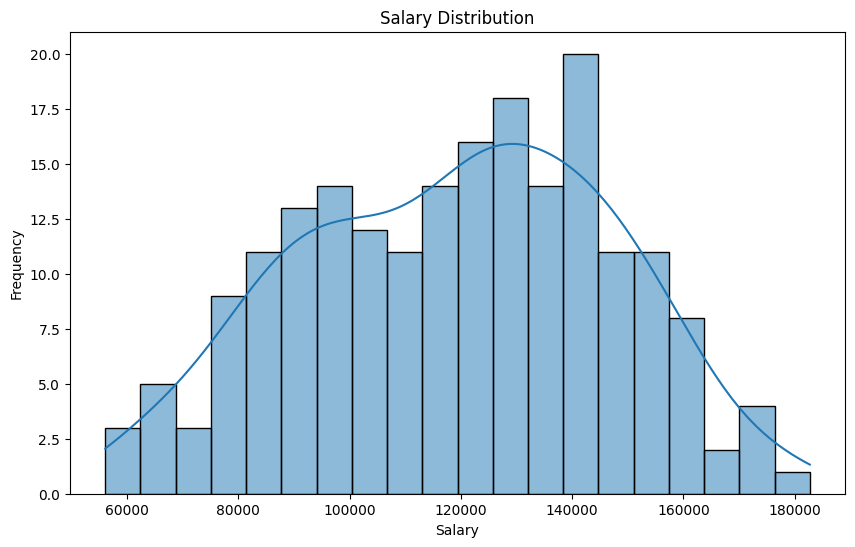

In [6]:
# 1 - HISTOGRAM
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.histplot(df['Salary'],kde=True,bins=20)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

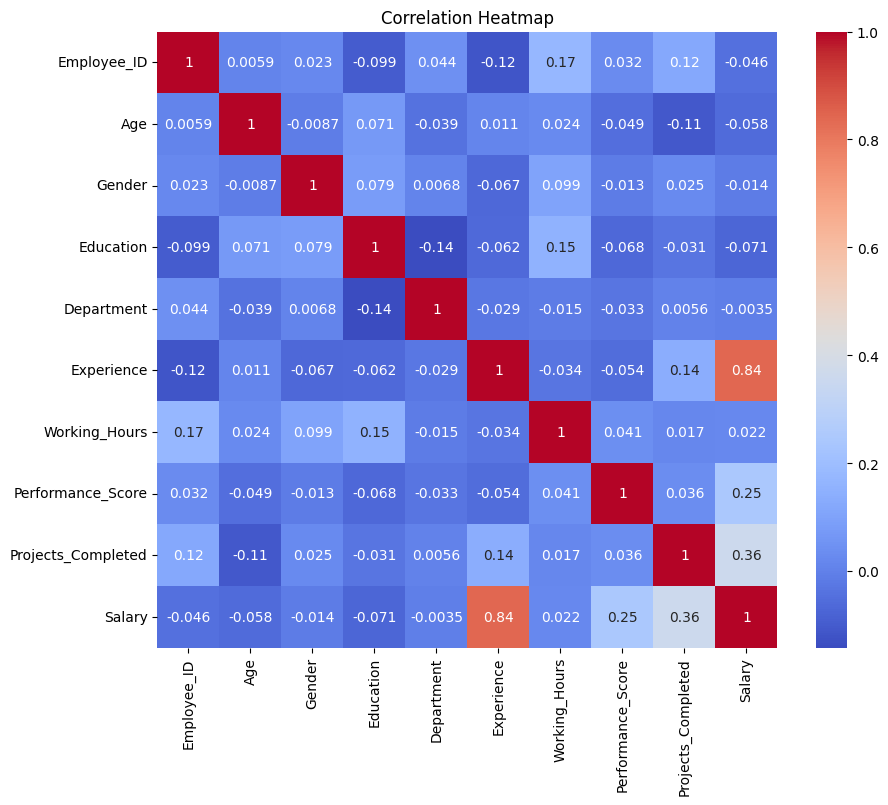

In [12]:
# 2- HEATMAP
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

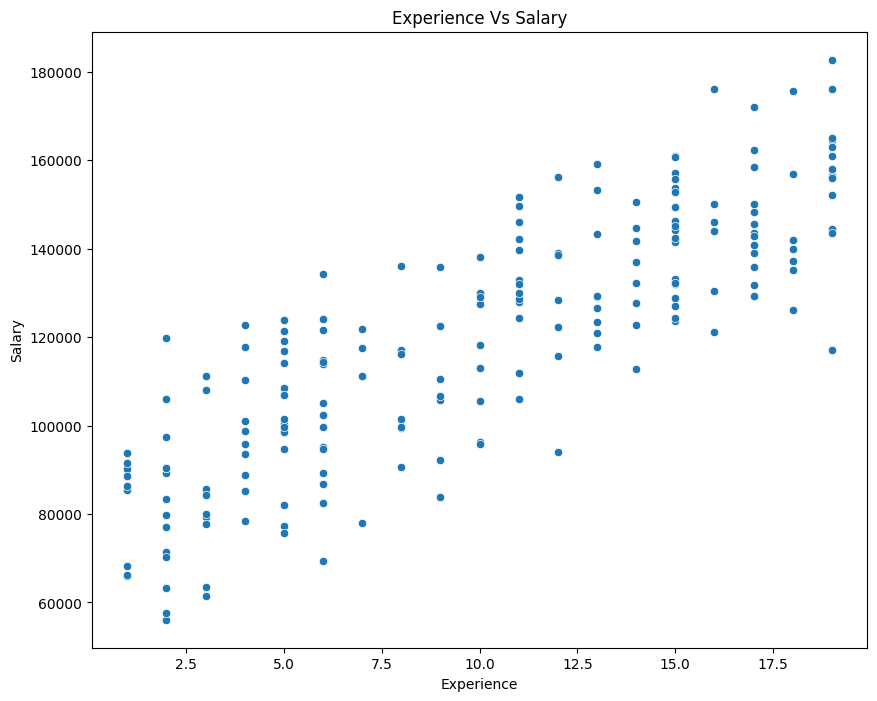

In [13]:
# 3 - SCATTER PLOT 
plt.figure(figsize=(10,8))
sns.scatterplot(x='Experience',y='Salary',data=df)
plt.title('Experience Vs Salary')
plt.show()

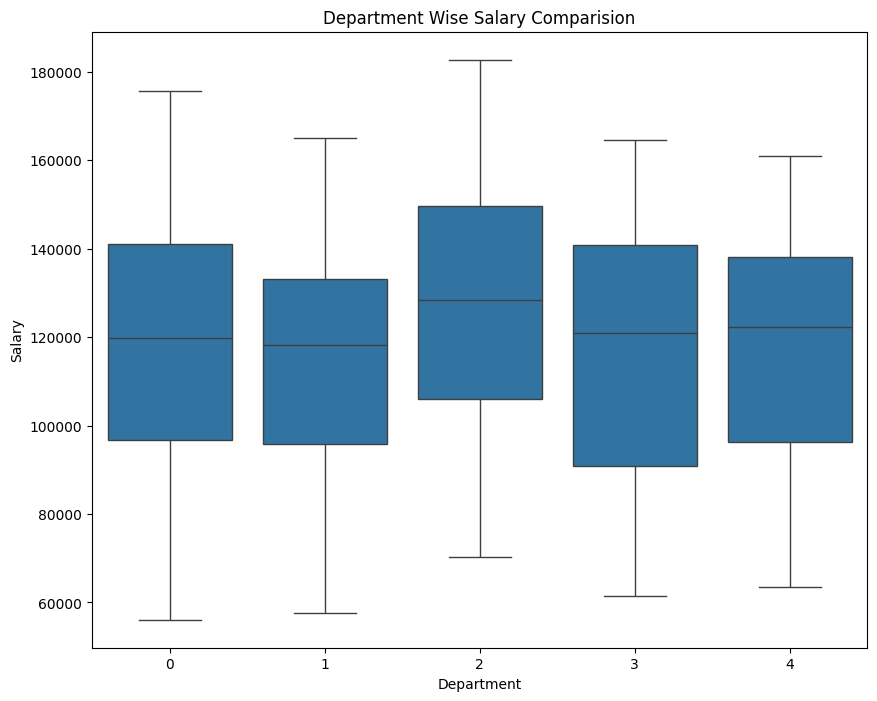

In [14]:
# 4 - BOXPLOT
plt.figure(figsize=(10,8))
sns.boxplot(x='Department',y='Salary',data=df)
plt.title('Department Wise Salary Comparision')
plt.show()

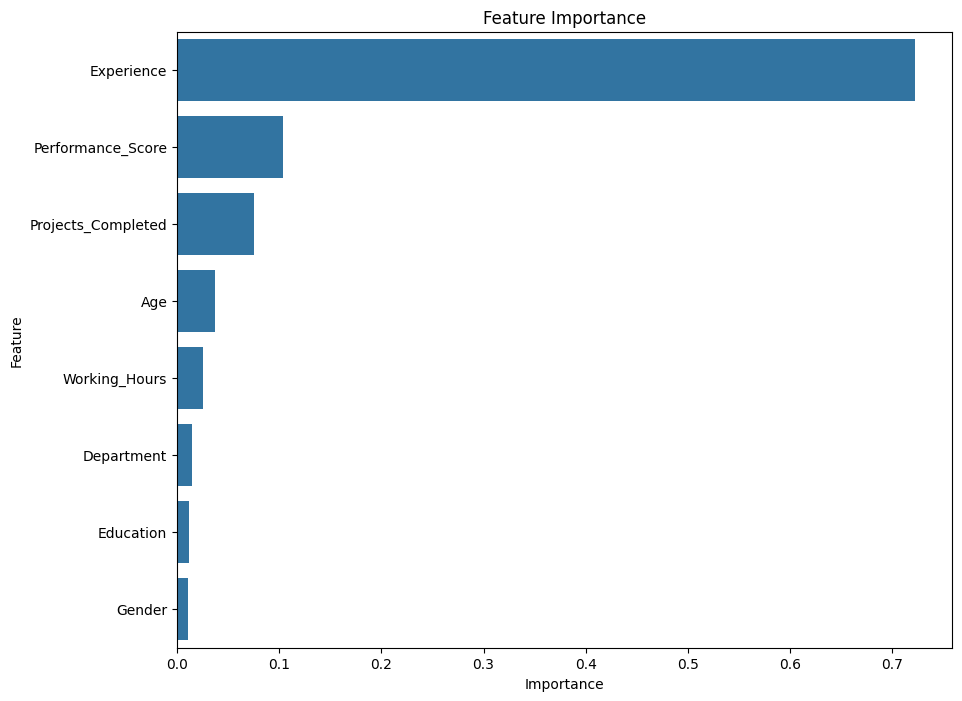

In [7]:
# 5 - BARPLOT
feature_importance=rf.feature_importances_
features=X.columns
importance_df=pd.DataFrame({
    'Feature':features,
    'Importance':feature_importance
})
importance_df=importance_df.sort_values(by='Importance',ascending=False)
plt.figure(figsize=(10,8))
sns.barplot(x='Importance',y='Feature',data=importance_df)
plt.title('Feature Importance')
plt.show()